# 9. Полный Transformer — Encoder-Decoder

**Цель:** Собрать полную seq2seq архитектуру трансформера: энкодер, декодер, эмбеддинги, выходную голову. Продемонстрировать авторегрессивную генерацию на задаче копирования.

---

In [1]:
# Teacher forcing: во время обучения декодер получает настоящую целевую последовательность (со сдвигом вправо),
# а не свои собственные предсказания — это ускоряет и стабилизирует обучение
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("transformer")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

2026-06-01 00:41:46,081 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data


2026-06-01 00:41:46,088 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:41:46,093 [DEBUG] matplotlib: interactive is False


2026-06-01 00:41:46,093 [DEBUG] matplotlib: platform is darwin


2026-06-01 00:41:46,121 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:41:46,123 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json


2026-06-01 00:41:46,249 [INFO] transformer: Используем устройство: mps


## 9.1 Компоненты трансформера

Переиспользуем все реализации из предыдущих ноутбуков в одном классе.

In [2]:
# Teacher forcing: декодер получает настоящие токены на обучении, а не свои предсказания — это ускоряет сходимость
# Каузальная маска в self-attention не даёт декодеру заглядывать в будущие позиции (авторегрессия)
log.debug("Assembling all transformer components")

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, mask=None):
        batch = Q.size(0)
        Q = self.W_Q(Q).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.d_model)
        return self.W_O(output)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = x + self.dropout1(self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # Causal self-attention: True = смотреть, False = маскировано
        seq_len = x.size(1)
        causal = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).bool()  # lower-tri = attend
        if tgt_mask is not None:
            # И позиция должна быть валидна (не pad) И не в будущем
            combined_mask = tgt_mask.unsqueeze(1).unsqueeze(2) & causal.unsqueeze(0).unsqueeze(0)
        else:
            combined_mask = causal.unsqueeze(0).unsqueeze(0)
        x = x + self.dropout1(self.self_attention(self.norm1(x), self.norm1(x), self.norm1(x), combined_mask))
        x = x + self.dropout2(self.cross_attention(self.norm2(x), self.norm2(encoder_output), self.norm2(encoder_output), src_mask))
        x = x + self.dropout3(self.ffn(self.norm3(x)))
        return x

log.debug("All components defined")

2026-06-01 00:41:46,260 [DEBUG] transformer: Assembling all transformer components


2026-06-01 00:41:46,261 [DEBUG] transformer: All components defined


## 9.2 PositionalEncoding

In [3]:
# Позиционное кодирование даёт трансформеру чувство порядка — модель не имеет врождённого понятия позиции
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

## 9.3 Полный Transformer

Объединяем всё: эмбеддинги, PE, энкодер, декодер, output head.

In [4]:
# Разница между обучением и инференсом:
# - Обучение: teacher forcing — декодер получает настоящую последовательность со сдвигом, весь выход за один проход
# - Инференс: авторегрессия — декодер подаёт своё предсказание на следующий шаг, по одному токену
log.debug("Implementing full Transformer model")

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, num_encoder_layers,
                 num_decoder_layers, d_ff=None, max_len=5000, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Эмбеддинги + позиционное кодирование
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        
        # Энкодер
        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])
        
        # Декодер
        self.decoder_layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])
        
        # Выходная голова (проекция в словарь)
        self.output_proj = nn.Linear(d_model, vocab_size)
        
        # Инициализация
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        
        log.info("Transformer: vocab=%d, d_model=%d, enc=%d, dec=%d, params=%d",
                 vocab_size, d_model, num_encoder_layers, num_decoder_layers,
                 sum(p.numel() for p in self.parameters()))
    
    def encode(self, src, src_mask=None):
        x = self.pos_encoding(self.embedding(src) * math.sqrt(self.d_model))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x
    
    def decode(self, tgt, encoder_output, src_mask=None, tgt_mask=None):
        x = self.pos_encoding(self.embedding(tgt) * math.sqrt(self.d_model))
        for layer in self.decoder_layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return x
    
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output = self.encode(src, src_mask)
        dec_output = self.decode(tgt, enc_output, src_mask, tgt_mask)
        return self.output_proj(dec_output)

log.debug("Transformer class defined")

2026-06-01 00:41:46,271 [DEBUG] transformer: Implementing full Transformer model


2026-06-01 00:41:46,272 [DEBUG] transformer: Transformer class defined


In [5]:
# Прямой проход с teacher forcing: декодер получает настоящие target токены (со сдвигом вправо), not model predictions — all positions computed in parallel
log.debug("Creating small transformer for testing")

vocab_size = 20
model = Transformer(
    vocab_size=vocab_size,
    d_model=32,
    n_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    d_ff=64,
    max_len=50,
).to(device)

src = torch.randint(0, vocab_size, (4, 10)).to(device)  # (batch, src_len)
tgt = torch.randint(0, vocab_size, (4, 8)).to(device)   # (batch, tgt_len)

output = model(src, tgt)
print(f"Source shape:          {src.shape}")
print(f"Target shape:          {tgt.shape}")
print(f"Output shape:          {output.shape}")
print(f"Output dim:            {output.shape[-1]} (should be {vocab_size})")
log.info("Full transformer forward pass OK")

2026-06-01 00:41:46,276 [DEBUG] transformer: Creating small transformer for testing


2026-06-01 00:41:46,278 [INFO] transformer: Transformer: vocab=20, d_model=32, enc=2, dec=2, params=43284


2026-06-01 00:41:46,686 [INFO] transformer: Full transformer forward pass OK


Source shape:          torch.Size([4, 10])
Target shape:          torch.Size([4, 8])
Output shape:          torch.Size([4, 8, 20])
Output dim:            20 (should be 20)


### Teacher forcing: обучение с учителем vs авторегрессия на инференсе

**Teacher forcing (обучение):**
```
Вход декодера: [BOS, t1, t2, t3]  (истинная последовательность)
Предсказание:  [p1, p2, p3, EOS]
Ошибка:        cross_entropy(p1, t1) + cross_entropy(p2, t2) + ...
```
- Декодер на каждом шаге получает **правильный предыдущий токен**, а не свой собственный
- Все позиции вычисляются **параллельно** — один forward вместо цикла
- Обучение быстрое и стабильное

**Авторегрессия (инференс):**
```
Шаг 1: [BOS]              → предсказание p1
Шаг 2: [BOS, p1]           → предсказание p2
Шаг 3: [BOS, p1, p2]       → предсказание p3
...
```
- Каждый следующий токен зависит от **собственных предыдущих предсказаний**
- Ошибки на ранних шагах накапливаются (exposure bias)
- Генерация последовательная — нельзя распараллелить

> Teacher forcing на трэйне, авторегрессия на инференсе — стандартная практика для seq2seq моделей.

## 9.4 Демонстрация: задача копирования

Обучим трансформер копировать последовательности.

In [6]:
# Задача копирования: копирование простых последовательностей проверяет, выучила ли модель механизм внимания
# Модель должна сопоставить каждую выходную позицию с соответствующей входной через cross-attention
# Если внимание сломано или неверно, модель не может копировать — идеальная минимальная диагностика
log.debug("Preparing copy task data")

from torch.utils.data import DataLoader, TensorDataset

BOS, EOS, PAD = 0, 1, 2  # специальные токены

def generate_copy_data(num_samples, max_len, vocab_size):
    """Генерирует пары src-tgt для задачи копирования."""
    src_list, tgt_list = [], []
    for _ in range(num_samples):
        length = np.random.randint(2, max_len + 1)
        seq = np.random.randint(3, vocab_size, size=length).tolist()
        src = [BOS] + seq + [EOS]
        src = src + [PAD] * (max_len + 2 - len(src))
        
        tgt_in = [BOS] + seq + [EOS]
        tgt_in = tgt_in + [PAD] * (max_len + 2 - len(tgt_in))
        
        tgt_out = seq + [EOS]
        tgt_out = tgt_out + [PAD] * (max_len + 2 - len(tgt_out))
        
        src_list.append(src)
        tgt_list.append(tgt_out)
    
    return (torch.tensor(src_list), torch.tensor(tgt_list))

vocab_size = 16
max_len = 6
train_src, train_tgt = generate_copy_data(500, max_len, vocab_size)
print(f"Train src shape: {train_src.shape}")
print(f"Train tgt shape: {train_tgt.shape}")
print(f"Source example:   {train_src[0].tolist()}")
print(f"Target example:   {train_tgt[0].tolist()}")
log.info("Copy task data generated")

2026-06-01 00:41:46,693 [DEBUG] transformer: Preparing copy task data


2026-06-01 00:41:46,716 [INFO] transformer: Copy task data generated


Train src shape: torch.Size([500, 8])
Train tgt shape: torch.Size([500, 8])
Source example:   [0, 5, 7, 1, 2, 2, 2, 2]
Target example:   [5, 7, 1, 2, 2, 2, 2, 2]


### Копирование последовательностей: почему это тестовая задача

Задача копирования — простейший тест seq2seq модели:

- **Вход:** последовательность токенов `[A, B, C]`
- **Выход:** та же последовательность `[A, B, C]`

Почему она полезна:
1. **Минимальная проверка внимания (attention):** модель должна выучить alignment между i-й позицией входа и i-й позицией выхода. Если cross-attention не работает — модель не сможет скопировать.
2. **Нет внешних знаний:** не нужны словари, грамматика, семантика — только способность "посмотреть" на вход.
3. **Известный oracle:** мы точно знаем, каким должен быть выход — метрика качества (accuracy) прозрачна.
4. **Диагностика:** если модель не сходится на копировании, она тем более не сработает на реальных данных.

Ожидаемый результат: после обучения loss ≈ 0, генерация ≈ 100% совпадение.

2026-06-01 00:41:46,723 [DEBUG] transformer: Training transformer on copy task


2026-06-01 00:41:46,726 [INFO] transformer: Transformer: vocab=16, d_model=32, enc=2, dec=2, params=43024


2026-06-01 00:41:48,164 [INFO] transformer: Epoch 0: loss=3.7741


2026-06-01 00:41:50,407 [INFO] transformer: Epoch 10: loss=1.2329


2026-06-01 00:41:52,661 [INFO] transformer: Epoch 20: loss=0.7399


...

2026-06-01 00:41:59,485 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansBuhid-Regular.ttf', name='Noto Sans Buhid', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:41:59,485 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Phosphate.ttc', name='Phosphate', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:41:59,486 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansInscriptionalParthian-Regular.ttf', name='Noto Sans Inscriptional Parthian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:41:59,486 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXNonUni.otf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:41:59,486 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0 to DejaVu Sans ('/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


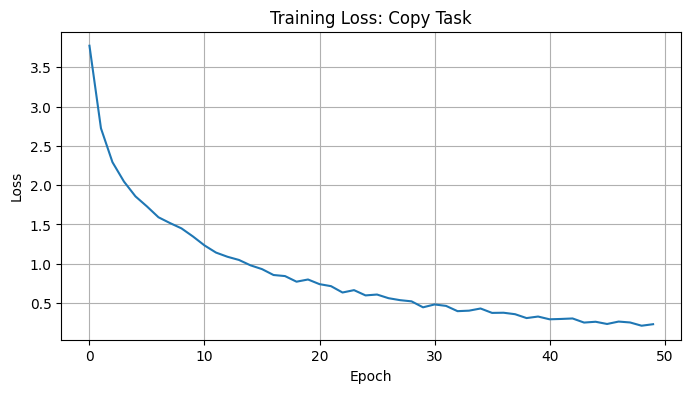

2026-06-01 00:41:59,536 [INFO] transformer: Training complete, final loss=0.2301


In [7]:
# Teacher forcing: вход декодера = BOS + target[:-1] (настоящий префикс, не предсказанные токены)
# На обучении модель видит правильную историю на каждом шаге — намного быстрее и стабильнее than autoregressive training
# Задача копирования требует от модели выучить правильное согласование энкодера и декодера через cross-attention
log.debug("Training transformer on copy task")

model_small = Transformer(
    vocab_size=vocab_size,
    d_model=32,
    n_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    d_ff=64,
    max_len=max_len + 2,
    dropout=0.1,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model_small.parameters(), lr=0.001)

n_epochs = 50
batch_size = 32
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    n_batches = 0
    perm = torch.randperm(len(train_src))
    
    for i in range(0, len(train_src), batch_size):
        idx = perm[i:i+batch_size]
        src = train_src[idx].to(device)
        tgt = train_tgt[idx].to(device)
        
        # Teacher forcing: вход декодера = BOS + target[:-1]
        dec_input = torch.cat([
            torch.full((len(idx), 1), BOS, device=device, dtype=torch.long),
            tgt[:, :-1]
        ], dim=1)
        
        output = model_small(src, dec_input)
        loss = criterion(output.reshape(-1, vocab_size), tgt.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_small.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    
    if epoch % 10 == 0:
        log.info("Epoch %d: loss=%.4f", epoch, avg_loss)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: Copy Task')
plt.grid(True)
plt.show()
log.info("Training complete, final loss=%.4f", losses[-1])

## 9.5 Авторегрессивная генерация

Генерируем последовательность по одному токену.

In [8]:
# Режим инференса: без teacher forcing — модель подаёт своё предсказание на следующий шаг (авторегрессия)
# Итеративная декодировка: по одному токену, каждый шаг зависит от всех сгенерированных ранее
# Жадная декодировка выбирает наиболее вероятный токен на каждом шаге (без beam search)
# Ключевое отличие: ошибки накапливаются при инференсе — модель видит свои собственные ошибки, not ground truth
log.debug("Implementing autoregressive generation")

@torch.no_grad()
def generate(model, src, max_len=10):
    model.eval()
    src = src.to(device)
    enc_output = model.encode(src)
    
    # Начинаем с BOS
    tgt = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=device)
    
    for i in range(max_len):
        dec_output = model.decode(tgt, enc_output)
        logits = model.output_proj(dec_output[:, -1:, :])  # только последний токен
        next_token = logits.argmax(dim=-1)  # greedy decoding
        tgt = torch.cat([tgt, next_token], dim=1)
        
        # Стоп при EOS
        if (next_token == EOS).all():
            break
    
    return tgt

test_src, _ = generate_copy_data(4, 4, vocab_size)
for i, src in enumerate(test_src[:3]):
    src = src.unsqueeze(0).to(device)
    pred = generate(model_small, src, max_len=12)
    src_tokens = [t for t in src[0].tolist() if t not in (BOS, EOS, PAD)]
    pred_tokens = [t for t in pred[0].tolist() if t not in (BOS, EOS, PAD)]
    print(f"Sample {i+1}: src={src_tokens}, pred={pred_tokens}, match={src_tokens == pred_tokens}")
log.info("Generation demo complete")

2026-06-01 00:41:59,542 [DEBUG] transformer: Implementing autoregressive generation


Sample 1: src=[14, 10], pred=[14, 10], match=True


2026-06-01 00:42:04,076 [INFO] transformer: Generation demo complete


Sample 2: src=[10, 6, 11, 4], pred=[10, 6, 11, 4], match=True
Sample 3: src=[12, 5, 5, 12], pred=[12, 5, 5, 12, 12], match=False


In [9]:
# Teacher forcing даёт быструю параллельную тренировку; авторегрессия работает на инференсе
# Задача копирования проверяет, что полный механизм encoder-decoder внимания работает корректно
print("=== Full Transformer complete ===")
print("Topics covered:")
print("  - Full Transformer: encoder + decoder + output head")
print("  - Tokenization with special tokens (BOS, EOS, PAD)")
print("  - Embeddings + PositionalEncoding")
print("  - Copy task: training with teacher forcing")
print("  - Autoregressive generation (greedy decoding)")
print(f"  - Final loss: {losses[-1]:.4f}")
log.info("Full transformer notebook complete")

2026-06-01 00:42:04,080 [INFO] transformer: Full transformer notebook complete


=== Full Transformer complete ===
Topics covered:
  - Full Transformer: encoder + decoder + output head
  - Tokenization with special tokens (BOS, EOS, PAD)
  - Embeddings + PositionalEncoding
  - Copy task: training with teacher forcing
  - Autoregressive generation (greedy decoding)
  - Final loss: 0.2301


📚 **Полезные ссылки:**
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)
- [The Annotated Transformer (Harvard NLP)](http://nlp.seas.harvard.edu/2018/04/03/attention.html)
